In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Set the project root for notebook execution.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from ml.preprocessing import preprocess_text

In [2]:
# Load and clean ticket text.
df = pd.read_csv(PROJECT_ROOT / "dataset/customer_support_data.csv")
df[["Ticket_Subject", "Ticket_Description"]] = df[["Ticket_Subject", "Ticket_Description"]].fillna("")
df["combined_text"] = df["Ticket_Subject"].astype(str) + " " + df["Ticket_Description"].astype(str)
df["clean_text"] = df["combined_text"].apply(preprocess_text)
df = df[df["clean_text"].str.strip() != ""].copy()
df[["Ticket_ID", "clean_text"]].head()

,Ticket_ID,clean_text
0,TKT-100000,hour operation individual hi support headquart...
1,TKT-100001,data syncing card hi support application crash...
2,TKT-100002,fa issue question hi support upgrade enterpris...
3,TKT-100003,login failed let hi support dashboard loading ...
4,TKT-100004,refund status attention hi support trying upda...


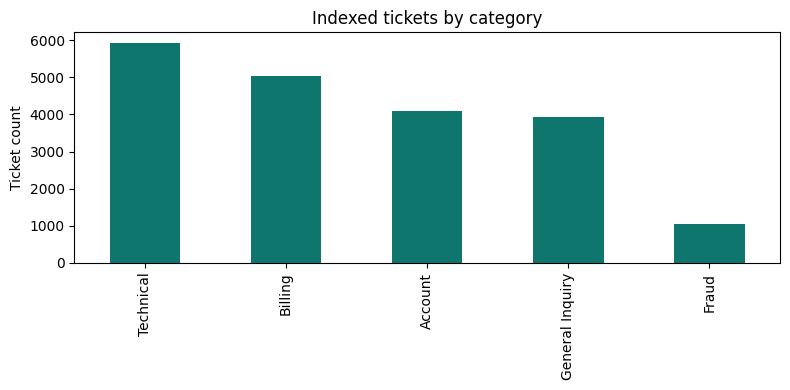

In [3]:
# Visualize the ticket volume used by the search index.
df["Issue_Category"].value_counts().plot.bar(figsize=(8, 4), color="#0f766e", title="Indexed tickets by category")
plt.xlabel("")
plt.ylabel("Ticket count")
plt.tight_layout()
plt.show()

In [4]:
# Build the TF-IDF search index.
similarity_vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
ticket_vectors = similarity_vectorizer.fit_transform(df["clean_text"])
similarity_data = df[["Ticket_ID", "Ticket_Subject", "Ticket_Description", "Issue_Category", "Priority_Level", "Resolution_Time_Hours", "Satisfaction_Score"]].copy()
print("Indexed tickets:", ticket_vectors.shape[0])
print("Vocabulary size:", ticket_vectors.shape[1])

Indexed tickets: 20000
Vocabulary size: 15000


In [5]:
# Save the search index for runtime predictions.
joblib.dump(similarity_vectorizer, PROJECT_ROOT / "models/similarity_vectorizer.pkl")
joblib.dump(ticket_vectors, PROJECT_ROOT / "models/ticket_vectors.pkl")
joblib.dump(similarity_data, PROJECT_ROOT / "models/similarity_data.pkl")
print("Similarity files saved.")

Similarity files saved.
